# Experiment 9 — Cross-sectional sentiment: does ranking stocks by news predict returns?

Experiments 1–8 tested **single-name TSLA** and found no forward signal. Documented
sentiment alpha lives in the **cross-section**: a per-name signal too weak to trade alone
can aggregate into a market-neutral edge across many names. This is the strongest remaining test.

**Hypothesis:** each day, ranking ~30 mega-caps by news sentiment predicts the cross-section
of **next-day** returns — high-sentiment names beat low-sentiment names (positive Information
Coefficient; profitable long-short portfolio net of costs).

**Attribution rule (key to signal quality):** an article counts for a stock only if that
stock's ticker/company name is in the **headline** — dropping the multi-tag listicle noise.

In [1]:
# 1. Setup + universe
import sys, re, html
from datetime import datetime, timezone
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, requests, torch
from scipy import stats
from transformers import AutoTokenizer, AutoModelForSequenceClassification

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "experiment_9" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT)); import get_bars as gb

MODEL_NAME = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
fb = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).eval()
device = "mps" if torch.backends.mps.is_available() else "cpu"; fb.to(device)
lab = {v.lower(): k for k, v in fb.config.id2label.items()}; POS, NEG = lab["positive"], lab["negative"]

# ticker -> company-name aliases (lowercase) for headline matching
UNIV = {
 "AAPL":["apple"],"MSFT":["microsoft"],"NVDA":["nvidia"],"AMZN":["amazon"],
 "META":["meta platforms","facebook","instagram"],"GOOGL":["google","alphabet"],
 "TSLA":["tesla"],"AVGO":["broadcom"],"JPM":["jpmorgan","jp morgan"],"V":["visa"],
 "WMT":["walmart"],"XOM":["exxon"],"JNJ":["johnson & johnson","johnson and johnson"],
 "MA":["mastercard"],"PG":["procter"],"HD":["home depot"],"COST":["costco"],
 "ORCL":["oracle"],"BAC":["bank of america"],"NFLX":["netflix"],"AMD":["advanced micro"],
 "CVX":["chevron"],"KO":["coca-cola","coca cola"],"PEP":["pepsi"],"ADBE":["adobe"],
 "CRM":["salesforce"],"DIS":["disney"],"INTC":["intel"],"QCOM":["qualcomm"],"PFE":["pfizer"],
}
TICKERS = list(UNIV)
START, END, ET = "2024-01-01T00:00:00Z", "2026-07-22T00:00:00Z", "America/New_York"
print(len(TICKERS), "names |", device)

/Users/georgia/Documents/Trading/sentimental_trading/trade_venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 34487.83it/s]

30 names | mps


## 2. Fetch Benzinga news for the universe

In [2]:
# 2. Paginated multi-symbol news pull
NEWS_URL = "https://data.alpaca.markets/v1beta1/news"
def get_news(symbols, start, end):
    params = {"symbols": ",".join(symbols), "start": start, "end": end, "limit": 50,
              "sort": "asc", "exclude_contentless": "true"}
    items, pages = [], 0
    while True:
        r = requests.get(NEWS_URL, headers=gb.HEADERS, params=params, timeout=30); r.raise_for_status()
        j = r.json(); items.extend(j.get("news", [])); pages += 1
        tok = j.get("next_page_token")
        if not tok: break
        params["page_token"] = tok
        if pages % 200 == 0: print(f"  {pages} pages, {len(items):,} items", end="\r")
    print(f"  fetched {len(items):,} items in {pages} pages")
    return items

raw = get_news(TICKERS, START, END)
art = pd.DataFrame([{"id": it["id"], "t_utc": it["created_at"],
                     "headline": it.get("headline","") or "", "summary": it.get("summary","") or ""}
                    for it in raw]).drop_duplicates("id")
art["date"] = pd.to_datetime(art["t_utc"], utc=True).dt.tz_convert(ET).dt.normalize().dt.tz_localize(None)
art = art[(art["date"] >= "2024-01-01") & (art["date"] < "2026-07-22")].reset_index(drop=True)
print(f"{len(art):,} unique articles")

  fetched 44,013 items in 881 pages
43,984 unique articles


## 3. Attribute articles to stocks by headline match

In [3]:
# 3. Headline attribution: article -> the universe stock(s) named in its headline
def matched_tickers(headline):
    hl_low = headline.lower(); hl_up = headline.upper()
    out = []
    for tk, aliases in UNIV.items():
        hit = any(a in hl_low for a in aliases)
        if not hit and len(tk) >= 3:                    # ticker as a standalone word (>=3 letters only)
            hit = re.search(rf"\b{tk}\b", hl_up) is not None
        if not hit and f"${tk}" in hl_up:
            hit = True
        if hit: out.append(tk)
    return out

art["match"] = art["headline"].apply(matched_tickers)
art_m = art[art["match"].map(len) > 0].reset_index(drop=True)
print(f"{len(art_m):,} / {len(art):,} articles name a universe stock in the headline "
      f"({len(art_m)/len(art):.0%})")
exploded = art_m.explode("match").rename(columns={"match": "ticker"})
print("\narticles per ticker (headline-attributed):")
print(exploded["ticker"].value_counts().to_string())

29,236 / 43,984 articles name a universe stock in the headline (66%)

articles per ticker (headline-attributed):
ticker
TSLA     5611
NVDA     4676
AAPL     3647
META     2273
GOOGL    2149
AMZN     2134
MSFT     2124
INTC     1147
AMD      1102
NFLX     1043
AVGO      794
ORCL      748
JPM       699
COST      626
DIS       611
WMT       565
CRM       518
ADBE      409
V         409
QCOM      406
BAC       393
PFE       387
XOM       377
HD        332
JNJ       310
MA        308
CVX       295
PEP       214
KO        175
PG        151


## 4. Score matched articles with FinBERT → daily per-ticker sentiment

In [4]:
# 4. Score each unique matched article once, then attribute
@torch.no_grad()
def finbert_scores(texts, bs=32, ml=256):
    out = []; n = len(texts)
    for i in range(0, n, bs):
        b = [t if isinstance(t, str) and t.strip() else "neutral" for t in texts[i:i+bs]]
        enc = tokenizer(b, return_tensors="pt", truncation=True, max_length=ml, padding=True).to(device)
        p = torch.softmax(fb(**enc).logits, dim=-1)
        out.extend((p[:, POS] - p[:, NEG]).cpu().numpy().tolist())
        if (i // bs) % 40 == 0: print(f"  {min(i+bs,n):,}/{n:,}", end="\r")
    return out

art_m["s"] = finbert_scores((art_m["headline"] + ". " + art_m["summary"]).str.slice(0, 400).tolist())
sc = art_m[["id", "date", "s", "match"]].explode("match").rename(columns={"match": "ticker"})
daily = sc.groupby(["date", "ticker"]).agg(S=("s", "mean"), n=("s", "size")).reset_index()
print(f"\n{len(daily):,} (date,ticker) sentiment observations")


12,791 (date,ticker) sentiment observations


## 5. Prices → next-day returns for all names

In [5]:
# 5. Multi-symbol daily bars
BARS_URL = "https://data.alpaca.markets/v2/stocks/bars"
def get_bars_multi(symbols, feed):
    params = {"symbols": ",".join(symbols), "timeframe": "1Day", "start": START,
              "end": datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ"),
              "limit": 10000, "adjustment": "split", "feed": feed, "sort": "asc"}
    bars = {}
    while True:
        r = requests.get(BARS_URL, headers=gb.HEADERS, params=params, timeout=30); r.raise_for_status()
        j = r.json()
        for sym, arr in (j.get("bars") or {}).items():
            bars.setdefault(sym, []).extend(arr)
        tok = j.get("next_page_token")
        if not tok: break
        params["page_token"] = tok
    return bars

try:
    bars = get_bars_multi(TICKERS, "sip"); feed_used = "sip"
except Exception:
    bars = get_bars_multi(TICKERS, "iex"); feed_used = "iex"

prc = []
for sym, arr in bars.items():
    d = pd.DataFrame(arr)
    d["date"] = pd.to_datetime(d["t"], utc=True).dt.tz_localize(None).dt.normalize()
    d = d.sort_values("date")
    d["fwd_ret"] = d["c"].pct_change().shift(-1)     # ret from t -> t+1
    d["ticker"] = sym
    prc.append(d[["date", "ticker", "c", "fwd_ret"]])
prices = pd.concat(prc, ignore_index=True)
print(f"{prices['ticker'].nunique()} names priced via {feed_used}, {len(prices):,} bars")

30 names priced via iex, 19,170 bars


## 6. Panel + cross-sectional Information Coefficient

In [6]:
# 6. Join sentiment with next-day returns; daily cross-sectional rank IC
panel = prices.merge(daily, on=["date", "ticker"], how="inner").dropna(subset=["fwd_ret", "S"])
panel = panel.sort_values(["date", "ticker"]).reset_index(drop=True)
panel.to_csv("xs_panel.csv", index=False)

def daily_ic(g):
    if g["S"].nunique() < 3 or len(g) < 10:
        return np.nan
    return stats.spearmanr(g["S"], g["fwd_ret"]).correlation

ic = panel.groupby("date").apply(daily_ic, include_groups=False).dropna()
mean_ic = ic.mean(); ic_t = mean_ic / (ic.std() / np.sqrt(len(ic)))
print(f"Cross-sectional next-day IC over {len(ic)} days:")
print(f"  mean IC  = {mean_ic:+.4f}")
print(f"  IC t-stat= {ic_t:+.2f}   (|t|>~2 => significant)")
print(f"  % positive days = {(ic > 0).mean():.1%}")
print(f"  avg names/day    = {panel.groupby('date').size().mean():.1f}")

Cross-sectional next-day IC over 636 days:


  mean IC  = +0.0149
  IC t-stat= +1.49   (|t|>~2 => significant)
  % positive days = 52.8%
  avg names/day    = 17.5


## 7. Long-short tercile portfolio (market-neutral) vs benchmark

In [7]:
# 7. Daily long top-third / short bottom-third by sentiment
def ls_day(g):
    if len(g) < 6:
        return pd.Series({"ls": np.nan, "longs": frozenset(), "shorts": frozenset(), "bench": g["fwd_ret"].mean()})
    q = g["S"].rank(pct=True)
    longs, shorts = g[q >= 2/3], g[q <= 1/3]
    return pd.Series({"ls": longs["fwd_ret"].mean() - shorts["fwd_ret"].mean(),
                      "longs": frozenset(longs["ticker"]), "shorts": frozenset(shorts["ticker"]),
                      "bench": g["fwd_ret"].mean()})

port = panel.groupby("date").apply(ls_day, include_groups=False).dropna(subset=["ls"])
# turnover (fraction of long/short book changing) and cost
prev_l = prev_s = frozenset()
turn = []
for _, r in port.iterrows():
    ch = len(r["longs"] ^ prev_l) + len(r["shorts"] ^ prev_s)
    denom = max(len(r["longs"]) + len(r["shorts"]), 1)
    turn.append(ch / (2 * denom)); prev_l, prev_s = r["longs"], r["shorts"]
port["turnover"] = turn
COST = 0.0005                                   # 5 bps per side per name traded
port["ls_net"] = port["ls"] - port["turnover"] * 2 * COST

ann = lambda r: (1 + r.mean())**252 - 1
sharpe = lambda r: r.mean() / r.std() * np.sqrt(252) if r.std() > 0 else np.nan
res = pd.DataFrame([
    {"strategy": "L/S gross", "ann_return": round(ann(port["ls"]), 4), "sharpe": round(sharpe(port["ls"]), 2),
     "total": round((1+port["ls"]).prod()-1, 3)},
    {"strategy": "L/S net of costs", "ann_return": round(ann(port["ls_net"]), 4), "sharpe": round(sharpe(port["ls_net"]), 2),
     "total": round((1+port["ls_net"]).prod()-1, 3)},
    {"strategy": "Equal-weight benchmark", "ann_return": round(ann(port["bench"]), 4), "sharpe": round(sharpe(port["bench"]), 2),
     "total": round((1+port["bench"]).prod()-1, 3)},
])
res.to_csv("xs_results.csv", index=False)
print(f"avg daily turnover: {port['turnover'].mean():.1%}")
res

avg daily turnover: 72.8%


,strategy,ann_return,sharpe,total
0,L/S gross,0.2215,0.92,0.564
1,L/S net of costs,0.0168,0.08,-0.017
2,Equal-weight benchmark,0.3237,1.37,0.930


## 8. Plots

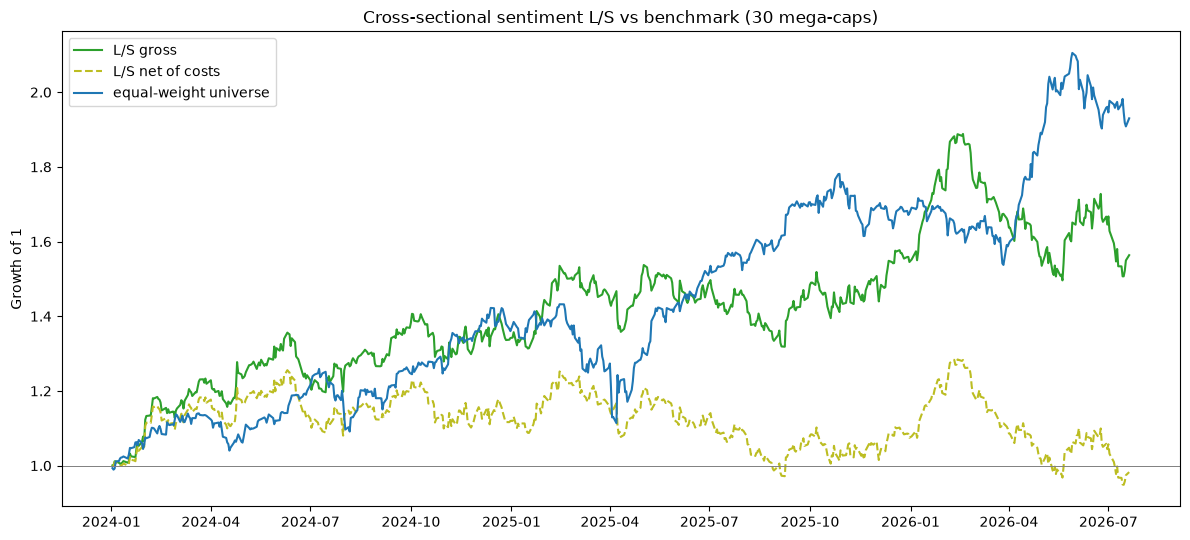

In [8]:
# 8a. Cumulative L/S vs benchmark
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(port.index, (1+port["ls"]).cumprod(), color="tab:green", label="L/S gross")
ax.plot(port.index, (1+port["ls_net"]).cumprod(), color="tab:olive", ls="--", label="L/S net of costs")
ax.plot(port.index, (1+port["bench"]).cumprod(), color="tab:blue", label="equal-weight universe")
ax.axhline(1, color="gray", lw=0.7)
ax.set_ylabel("Growth of 1"); ax.set_title("Cross-sectional sentiment L/S vs benchmark (30 mega-caps)")
ax.legend(); plt.tight_layout(); plt.show()

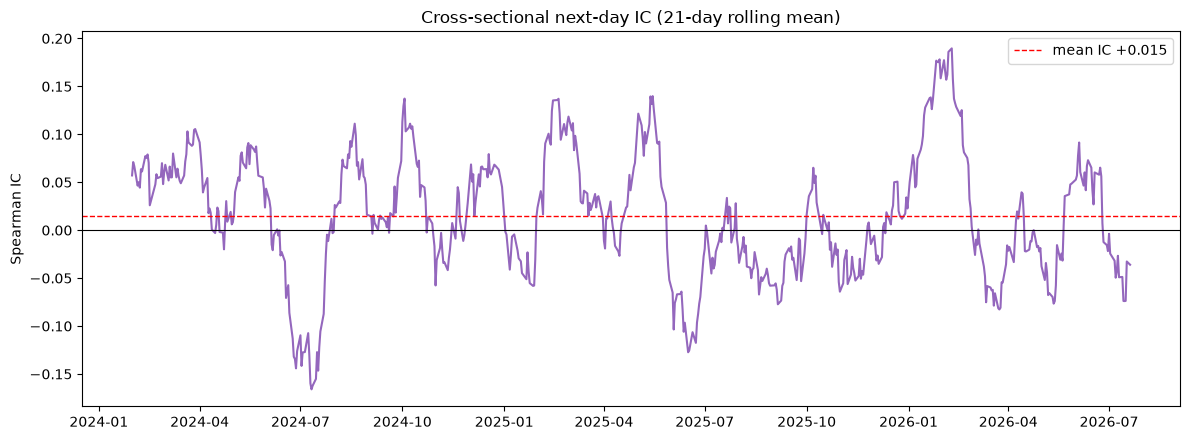

In [9]:
# 8b. Rolling 21-day mean IC
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(ic.index, ic.rolling(21).mean(), color="tab:purple")
ax.axhline(0, color="black", lw=0.8); ax.axhline(mean_ic, color="red", ls="--", lw=1, label=f"mean IC {mean_ic:+.3f}")
ax.set_title("Cross-sectional next-day IC (21-day rolling mean)"); ax.set_ylabel("Spearman IC")
ax.legend(); plt.tight_layout(); plt.show()

## 9. Verdict

In [10]:
# 9. Verdict
gross, net, bench = res.iloc[0], res.iloc[1], res.iloc[2]
print("HYPOTHESIS: cross-sectional sentiment predicts next-day relative returns")
print("=" * 74)
print(f"Mean daily IC = {mean_ic:+.4f}  (t = {ic_t:+.2f}, {(ic>0).mean():.0%} positive days)")
print(res.to_string(index=False))
print("=" * 74)

ic_sig = abs(ic_t) > 2 and mean_ic > 0
beats_net = net["sharpe"] > bench["sharpe"] and net["ann_return"] > 0
if ic_sig and beats_net:
    v = "SUPPORTED — significant positive IC AND a L/S that beats the benchmark net of costs. Worth a proper factor-neutral, larger-universe study."
elif ic_sig:
    v = "PARTIAL — IC is significant, but the L/S does not beat the benchmark net of costs (eaten by turnover). A real but likely uneconomic signal at this frequency/universe."
else:
    v = "NOT SUPPORTED — cross-sectional sentiment shows no significant IC; even aggregated across names, headline sentiment does not predict relative returns."
print("VERDICT:", v)
print("Saved -> xs_panel.csv, xs_results.csv")

HYPOTHESIS: cross-sectional sentiment predicts next-day relative returns
Mean daily IC = +0.0149  (t = +1.49, 53% positive days)
              strategy  ann_return  sharpe  total
             L/S gross      0.2215    0.92  0.564
      L/S net of costs      0.0168    0.08 -0.017
Equal-weight benchmark      0.3237    1.37  0.930
VERDICT: NOT SUPPORTED — cross-sectional sentiment shows no significant IC; even aggregated across names, headline sentiment does not predict relative returns.
Saved -> xs_panel.csv, xs_results.csv


### Reading this

- **IC t-stat** is the key stat: |t|>2 with positive mean IC = a real cross-sectional signal.
  Typical real sentiment ICs are tiny (0.02–0.05) but can be significant over hundreds of days.
- A significant IC that **doesn't survive costs** (net L/S ≤ benchmark) is the common real-world
  outcome: the edge exists but turnover eats it at this universe size / daily frequency.
- ~30 names + terciles is coarse; a genuine positive here would justify scaling to a
  few-hundred-name universe with sector/beta neutralization before believing it.